<a href="https://colab.research.google.com/github/Maryam-Taherzadeh/Computational-Drug-Discovery/blob/main/project-01-predict-ic50-mdm2-p53/notebooks/mdm2_part6_xgboost_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🧪 Part 6: XGBoost Model Development, Model Comparison, and Feature Importance

**Author: Maryam Taherzadeh**

In this section, machine learning models were developed to predict the bioactivity (**pIC50**) of MDM2 inhibitors using molecular descriptors.

Based on benchmarking results from Part 5, **XGBoost** was selected as the primary model due to its strong performance and ability to capture complex nonlinear relationships in high-dimensional data.

To ensure a comprehensive comparison, **Random Forest** and **Support Vector Regression (SVR)** were also implemented. SVR was further optimized using **RandomizedSearchCV** to identify the best hyperparameters.

---

### 🎯 Objective

- Develop a robust regression model for pIC50 prediction  
- Compare multiple machine learning models:
  - Random Forest (baseline)
  - SVR (tuned using RandomizedSearchCV)
  - XGBoost (final optimized model)  
- Optimize XGBoost through hyperparameter tuning  
- Evaluate models using regression metrics (R², MAE, MSE)  
- Identify important molecular features  

---

### ⚙️ Workflow

1. Load preprocessed dataset  
2. Split data into training and testing sets  
3. Train **Random Forest** as a baseline model  
4. Train and tune **SVR using RandomizedSearchCV**  
5. Train baseline **XGBoost** model  
6. Perform **XGBoost hyperparameter tuning**  
7. Evaluate and compare model performance  
8. Analyze **feature importance**  

---

### ⚠️ Notes on Model Design

- **Feature Scaling:**
  - Applied to SVR using `StandardScaler`
  - Not required for Random Forest and XGBoost

- **Hyperparameter Optimization:**
  - SVR → RandomizedSearchCV (efficient search over large space)  
  - XGBoost → RandomizedSearchCV / tuning  

---

## **1. Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Load the data set**


In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/mdm2_07_padel_descriptors_pIC50.csv')
df.shape

Mounted at /content/drive


(5792, 882)

In [3]:
X = df.drop('pIC50', axis=1)
y = df.pIC50

## **3. Input features**

The MDM2 dataset contains 881 molecular descriptors generated using PaDEL. These descriptors numerically represent the chemical structure of each compound and are used as input features for machine learning.

The output variable is pIC50, which quantifies the inhibitory activity of compounds against the MDM2 target. Lower IC50 values (and thus higher pIC50 values) indicate stronger inhibitory activity.

### **4. Data pre-processing**

In [4]:
# Examine X dimension
X.shape

(5792, 881)

In [5]:
y.shape

(5792,)

##**5. Data split (80/20 ratio)**

In [6]:
# Perform data splitting using 80/20 ratio
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_train.shape, y_train.shape
X_test.shape, y_test.shape

((1159, 881), (1159,))

## **6. Building a regression model with XGBOOST**




---



---



In [7]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split


In [8]:

# Build baseline model
xgb_model = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)



# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_base = xgb_model.predict(X_test)
# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_base = xgb_model.predict(X_test)



##**7. Evaluate Moldel Performance**

In [9]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# Evaluate
r2_base = r2_score(y_test, y_pred_base)
mse_base = mean_squared_error(y_test, y_pred_base)
mae_base = mean_absolute_error(y_test, y_pred_base)


print("=== XGBoost Baseline Results ===")
print(f"R²  : {r2_base:.4f}")
print(f"MSE : {mse_base:.4f}")
print(f"MAE : {mae_base:.4f}")
print("MAE:", mae_base)

=== XGBoost Baseline Results ===
R²  : 0.6539
MSE : 0.7018
MAE : 0.6037
MAE: 0.6037109871639056


##**8. Scatter Plot of Experimental vs Predicted pIC50 Values**


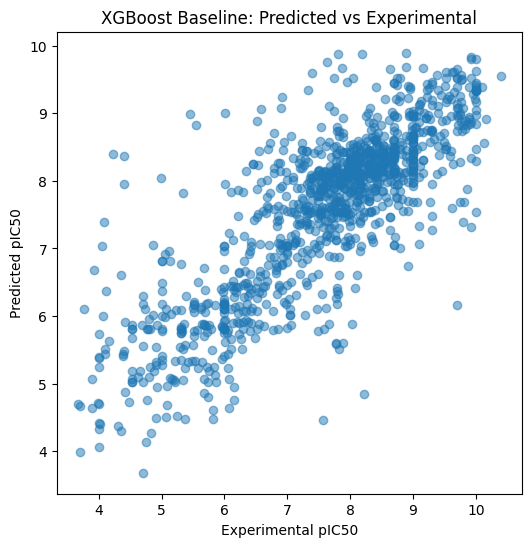

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_base, alpha=0.5)
plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")
plt.title("XGBoost Baseline: Predicted vs Experimental")
plt.show()

## **9. Hyperparameter tuning (MOST IMPACT)**

###  Note: Hyperparameter Optimization using Randomized Search

In this step, **RandomizedSearchCV** was used to optimize the hyperparameters of the XGBoost model.

Unlike Grid Search, which evaluates all possible parameter combinations, Randomized Search samples a subset of the search space. This approach significantly reduces computational cost while still identifying high-performing parameter configurations.

This is especially important for XGBoost, where the number of possible parameter combinations is large and exhaustive search would be computationally expensive.

---

###  Model Retraining with Optimal Parameters

After hyperparameter tuning, the model was **retrained using the best parameter combination** identified by RandomizedSearchCV.

The optimized model (`best_estimator_`) was then evaluated on the test set to measure its generalization performance.

This ensures that the final model benefits from improved parameter settings while being validated on unseen data.



*   List item
*   List item



In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Base XGBoost model
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
param_dist = {
    'n_estimators': [100, 200, 300, 500, 800],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 5]
}

# Random Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:")
print(random_search.best_params_)

print("Best CV R²:")
print(random_search.best_score_)


## **Now Evaluate on test**


In [12]:
# Best model
best_xgb = random_search.best_estimator_
# Predict on test set
y_pred_xgb = best_xgb.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Test R²:", r2_score(y_test, y_pred_xgb))
print("Test MSE:", mean_squared_error(y_test, y_pred_xgb))
print("Test MAE:", mean_absolute_error(y_test, y_pred_xgb))

Test R²: 0.6722196597148666
Test MSE: 0.6646791191713957
Test MAE: 0.5998168272311866


##**Predicted vs Experimental pIC50 (XGBoost Model)**

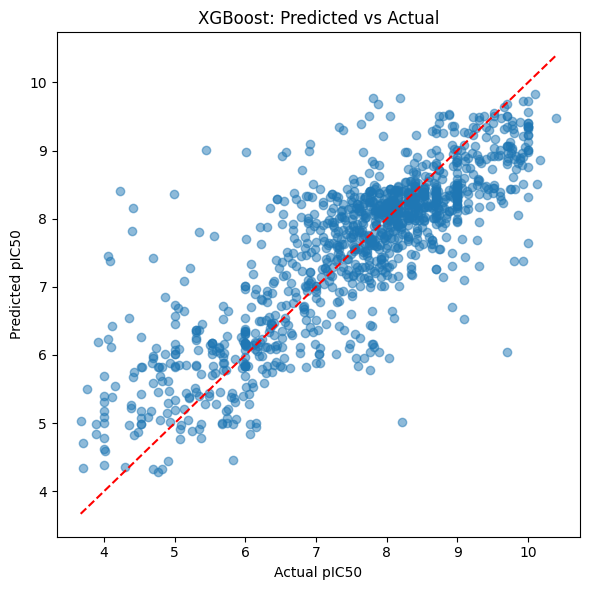

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("XGBoost: Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.tight_layout()
plt.show()

##**Residual Analysis of XGBoost Model Predictions**


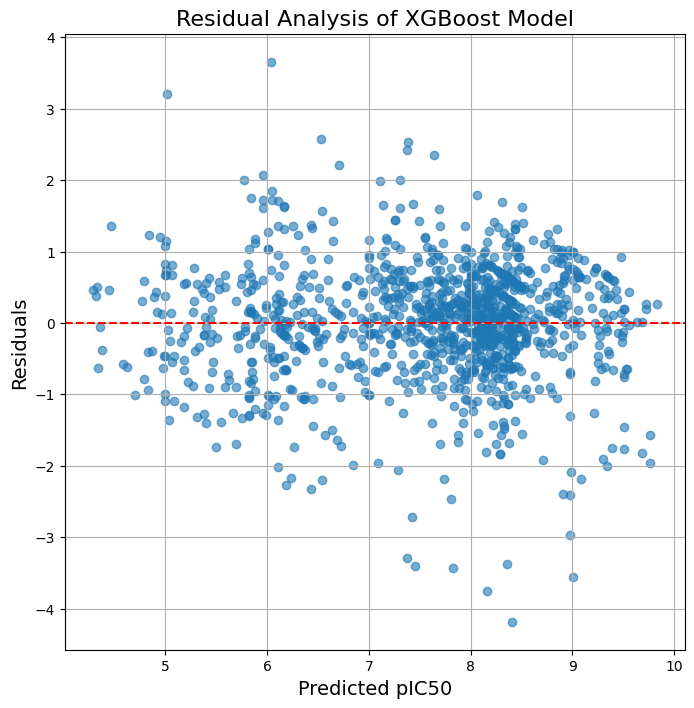

In [32]:
residuals = y_test - y_pred_xgb

plt.figure(figsize=(8,8))

plt.scatter(y_pred_xgb, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted pIC50", fontsize=14)
plt.ylabel("Residuals", fontsize=14)
plt.title("Residual Analysis of XGBoost Model", fontsize=16)

plt.grid(True)
plt.show()

##Note:

The residual plot shows that prediction errors are randomly distributed around zero, indicating that the model does not exhibit significant bias. A slight increase in variance at higher pIC50 values suggests reduced prediction accuracy for highly potent compounds.

<Figure size 1000x800 with 0 Axes>

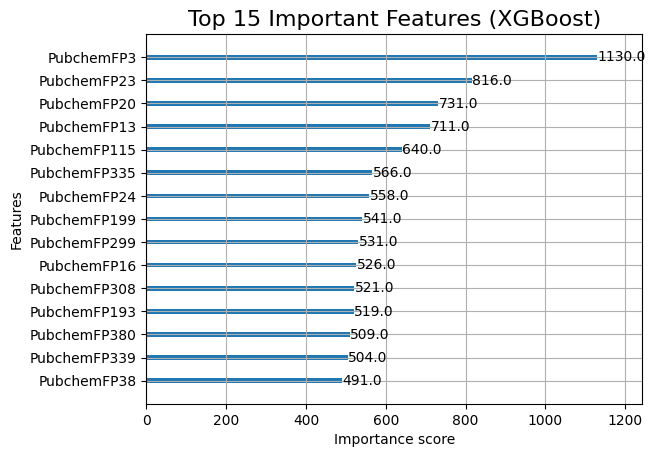

In [37]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plot_importance(best_xgb, max_num_features=15)

plt.title("Top 15 Important Features (XGBoost)", fontsize=16)
plt.show()

## **Key Molecular Descriptors Driving pIC50 Prediction**

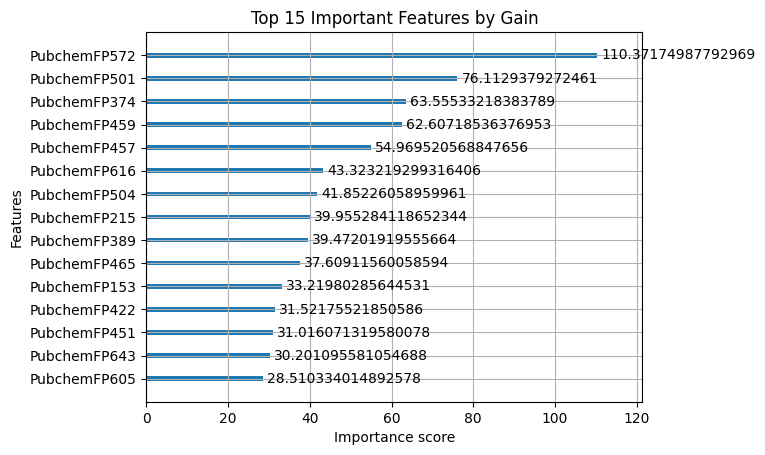

In [38]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(
    best_xgb,
    max_num_features=15,
    importance_type="gain"
)

plt.title("Top 15 Important Features by Gain")
plt.show()



## **Key Molecular Features Driving Prediction**


Feature importance analysis based on gain reveals that specific PubChem fingerprint descriptors (e.g., PubchemFP572, PubchemFP501, PubchemFP374) play a critical role in predicting pIC50 values. These features likely represent important structural motifs associated with MDM2 inhibition.

Gain-based importance was used as it reflects the contribution of each feature to improving model accuracy.

In [39]:
import pandas as pd

booster = best_xgb.get_booster()

score = booster.get_score(importance_type="gain")

feat_df = pd.DataFrame({
    "Feature": list(score.keys()),
    "Importance": list(score.values())
}).sort_values(by="Importance", ascending=False)

feat_df.head(15)

,Feature,Importance
301,PubchemFP572,110.371750
239,PubchemFP501,76.112938
133,PubchemFP374,63.555332
202,PubchemFP459,62.607185
201,PubchemFP457,54.969521
338,PubchemFP616,43.323219
242,PubchemFP504,41.852261
76,PubchemFP215,39.955284
147,PubchemFP389,39.472019
206,PubchemFP465,37.609116


In [14]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
df3 = pd.read_csv('my_bioactivity_data.csv')
df3.shape

Saving my_bioactivity_data.csv to my_bioactivity_data.csv


(5792, 9)

In [16]:
df3

,molecule_chembl_id,canonical_smiles,bioactivity_class,mol,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL178578,O=C(O)[C@H](c1ccccc1)N1C(=O)c2cc(I)ccc2NC(=O)[...,intermediate,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc297e0>,580.300,5.27150,2,3,5.769551
1,CHEMBL361103,O=C(O)[C@H](c1ccc(Cl)cc1)N1C(=O)c2cc(I)ccc2NC(...,active,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc299a0>,581.193,5.55950,2,3,6.698970
2,CHEMBL182051,C[C@H](c1ccc(Cl)cc1)N(C(=O)/C=C/c1ccccc1)[C@H]...,inactive,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc29a10>,453.369,5.82300,1,2,4.522879
3,CHEMBL360540,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2)N(CCCC...,inactive,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc29a80>,551.470,6.76250,1,3,4.886057
4,CHEMBL427316,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2Br)N(CC...,intermediate,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc29af0>,630.366,7.52500,1,3,5.443697
...,...,...,...,...,...,...,...,...,...
5787,CHEMBL6014971,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...,active,<rdkit.Chem.rdchem.Mol object at 0x7e8fb4151380>,568.417,5.72350,0,8,9.619789
5788,CHEMBL5805098,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...,active,<rdkit.Chem.rdchem.Mol object at 0x7e8fb41513f0>,547.999,5.37852,0,8,9.161151
5789,CHEMBL6045300,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...,active,<rdkit.Chem.rdchem.Mol object at 0x7e8fb4151460>,565.421,5.03750,0,8,8.543634
5790,CHEMBL6055628,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...,active,<rdkit.Chem.rdchem.Mol object at 0x7e8fb41514d0>,564.433,5.64250,0,7,9.602060


## **Top 10 Candidate MDM2 Inhibitors Identified by Machine Learning Model**

I trained an XGBoost regression model to predict pIC50 values from molecular descriptors.
After predicting on unseen compounds, I ranked them by predicted pIC50 and selected the top 10 candidates.
These represent the most promising MDM2 inhibitors and can be prioritized for docking, ADMET analysis, or experimental validation.
This approach enables efficient virtual screening and reduces the search space significantly.

,molecule_chembl_id,canonical_smiles,Predicted_pIC50,Actual_pIC50
1103,CHEMBL3657040,COc1ccc(CNC(=O)CO)cc1-c1nc2c(n1C(C)C)C(c1ccc(C...,9.829151,10.096910
810,CHEMBL3407554,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,9.764757,7.809668
809,CHEMBL3407555,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(...,9.764757,8.193820
4751,CHEMBL3318760,CC(C)NS(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(CC...,9.728711,10.000000
776,CHEMBL3318763,C[C@]1(CC(=O)O)C[C@H](c2cccc(Cl)c2)[C@@H](c2cc...,9.728476,9.920819
1129,CHEMBL3657030,COc1ccc(C(=O)NCCO)cc1-c1nc2c(n1C(C)C)[C@@H](c1...,9.689064,7.872895
4653,CHEMBL6005050,CCS(=O)(=O)N(C[C@H](C1CC1)N1C(=O)[C@@](C)(CC(=...,9.684414,9.698970
800,CHEMBL3318787,CC(C)(C)[C@@H](CS(=O)(=O)N1CCc2cc(F)ccc21)N1C(...,9.637629,9.657577
505,CHEMBL3125520,C[C@]1(CC(=O)O)C[C@H](c2cccc(Cl)c2)[C@@H](c2cc...,9.562318,10.000000
4697,CHEMBL4108486,C[C@]1(CC(=O)O)C[C@H](c2cccc(Cl)c2)[C@@H](c2cc...,9.558016,9.522879


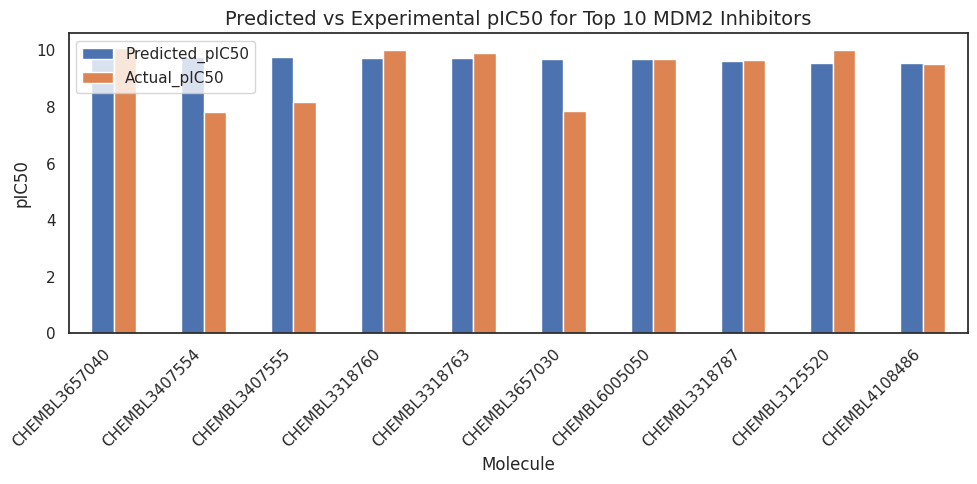

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# Top 10 MDM2 Candidates
# Predicted vs Actual pIC50
# =============================

# Step 1: Make sure indices are clean
df3 = df3.reset_index(drop=True)

# Step 2: Get test indices
test_idx = X_test.index

# Step 3: Create results dataframe from test molecules
results = df3.loc[test_idx].copy()

# Step 4: Add predicted and actual pIC50 values
results["Predicted_pIC50"] = y_pred_xgb
results["Actual_pIC50"] = y_test.values

# Step 5: Rank molecules by predicted pIC50
top_ligands = results.sort_values(
    by="Predicted_pIC50",
    ascending=False
)

# Step 6: Select top 10 candidates
top10 = top_ligands.head(10).copy()

# Step 7: Display table
display(top10[[
    "molecule_chembl_id",
    "canonical_smiles",
    "Predicted_pIC50",
    "Actual_pIC50"
]])

# Step 8: Plot predicted vs actual pIC50
top10_plot = top10[[
    "molecule_chembl_id",
    "Predicted_pIC50",
    "Actual_pIC50"
]]

top10_plot.set_index("molecule_chembl_id").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Predicted vs Experimental pIC50 for Top 10 MDM2 Inhibitors", fontsize=14)
plt.ylabel("pIC50")
plt.xlabel("Molecule")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## **Top 10 Predicted MDM2 Inhibitors: Molecular Structure Visualization**

In [31]:
!pip install rdkit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 47.7 MB/s eta 0:00:00


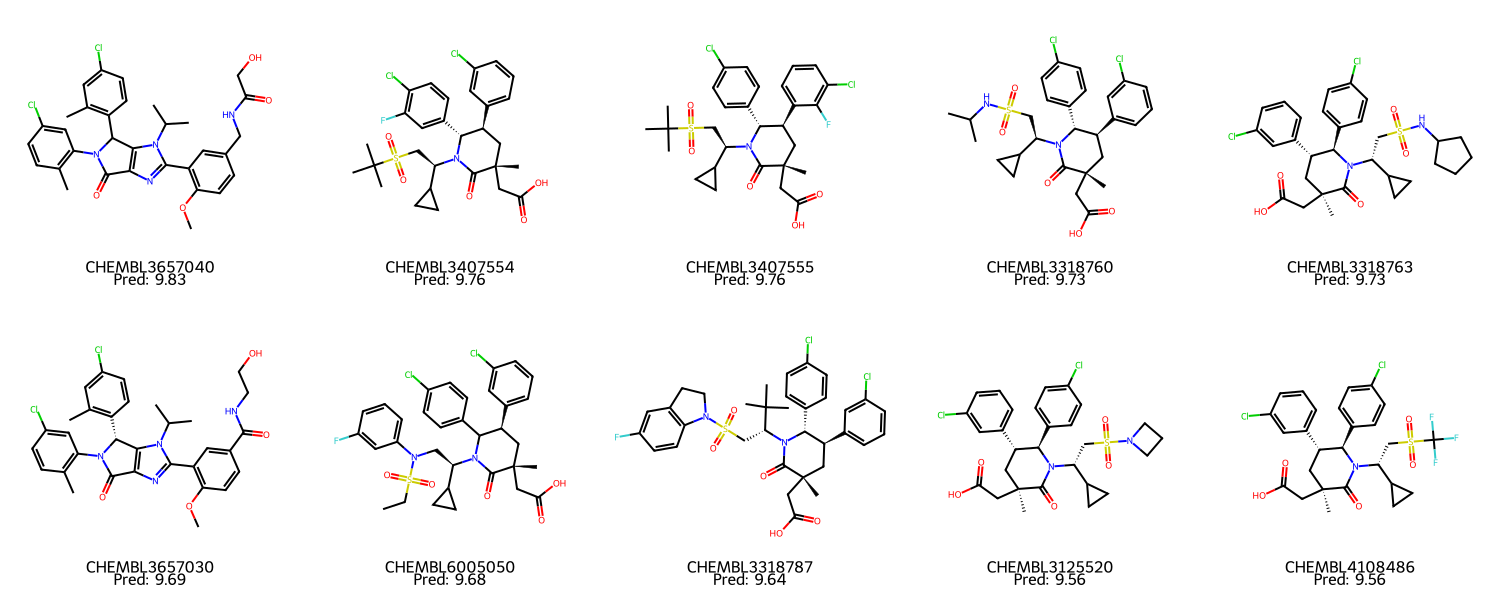

In [35]:
from rdkit import Chem
from rdkit.Chem import Draw

# -----------------------------
# Step 1: Create labels
# -----------------------------
labels = [
    f"{row['molecule_chembl_id']}\nPred: {row['Predicted_pIC50']:.2f}"
    for _, row in top10.iterrows()
]

# -----------------------------
# Step 2: Convert SMILES to molecules
# -----------------------------
mols = []
valid_labels = []

for i, sm in enumerate(top10['canonical_smiles']):
    mol = Chem.MolFromSmiles(sm)
    if mol is not None:  # avoid broken SMILES
        mols.append(mol)
        valid_labels.append(labels[i])

# -----------------------------
# Step 3: Draw grid image
# -----------------------------
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=5,
    subImgSize=(300, 300),
    legends=valid_labels
)

img


## **Extracted feature importance scores from the tuned XGBoost model**

In [38]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Get feature importance from your tuned XGBoost model
importances = best_xgb.feature_importances_

feat_importance = pd.Series(importances, index=X_train.columns)

# 2. Select top 200 features
top_features = feat_importance.nlargest(200).index

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

print("Original X_train shape:", X_train.shape)
print("Top feature X_train shape:", X_train_top.shape)

# 3. Train XGBoost again using same best parameters
best_params = random_search.best_params_

xgb_top = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_top.fit(X_train_top, y_train)

# 4. Predict
y_pred_top = xgb_top.predict(X_test_top)

# 5. Evaluate
print("Top 200 Features XGBoost Performance:")
print("R²:", r2_score(y_test, y_pred_top))
print("MSE:", mean_squared_error(y_test, y_pred_top))
print("MAE:", mean_absolute_error(y_test, y_pred_top))

Original X_train shape: (4633, 881)
Top feature X_train shape: (4633, 200)
Top 200 Features XGBoost Performance:
R²: 0.6661356395298084
MSE: 0.6770164093642965
MAE: 0.6073929217541895


## *Note:*


In this step, feature importance scores from the tuned XGBoost model were used to reduce the dimensionality of the dataset.

Original feature set: 881 features
Reduced feature set: Top 200 most important features

The model was retrained using only the selected features, and performance was evaluated on the test set.

| Model             | Features | R²         | MSE        | MAE        |
| ----------------- | -------- | ---------- | ---------- | ---------- |
| XGBoost (Full)    | 881      | **0.6722** | **0.6647** | **0.5998** |
| XGBoost (Top 200) | 200      | 0.6661     | 0.6770     | 0.6074     |



Interpretation:

The reduced model achieved performance very close to the full model
This indicates that:
Most predictive information is captured by a smaller subset of features
Many original features are redundant or less informative

🎯 Conclusion

Feature selection using XGBoost importance allows for:

Significant reduction in dimensionality (~77%)
Minimal loss in predictive performance
Improved model efficiency and interpretability

## **10. Building a regression model with Support Vector Machine**


In [43]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Step 1: Pipeline for X
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=1, epsilon=0.1, gamma="scale"))
])

# Step 2: Wrap model to scale y
svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler()
)

# Train
svr_model.fit(X_train, y_train)

# Predict (automatically inverse-transformed)
y_pred_svr = svr_model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)
mae = mean_absolute_error(y_test, y_pred_svr)

print("SVR (X and y scaled) Performance:")
print("R²:", r2)
print("MSE:", mse)
print("MAE:", mae)

SVR (X and y scaled) Performance:
R²: 0.6402884443645239
MSE: 0.7294298362970028
MAE: 0.6078228139535368



## **Note**
Unlike Random Forest and XGBoost, SVR requires feature scaling because it uses distance-based calculations. Therefore, StandardScaler was applied before training the SVR model.

## **11. Hyperparameter tuning (MOST IMPACT)**


In [44]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

param_dist = {
    "svr__C": np.logspace(-1, 3, 20),        # 0.1 → 1000
    "svr__epsilon": np.linspace(0.01, 0.5, 20),
    "svr__gamma": ["scale", "auto"] + list(np.logspace(-4, 0, 10)),
    "svr__kernel": ["rbf"]
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=30,        # increase if you have time
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)

Best params: {'svr__kernel': 'rbf', 'svr__gamma': np.float64(0.0002782559402207126), 'svr__epsilon': np.float64(0.1131578947368421), 'svr__C': np.float64(54.555947811685144)}
Best CV R²: 0.6442274103659592


## **Now evaluate on Test set**


In [45]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

best_svr = random_search.best_estimator_

y_pred_svr = best_svr.predict(X_test)

print("Tuned SVR Test Performance:")
print("R²:", r2_score(y_test, y_pred_svr))
print("MSE:", mean_squared_error(y_test, y_pred_svr))
print("MAE:", mean_absolute_error(y_test, y_pred_svr))

Tuned SVR Test Performance:
R²: 0.6503893705987325
MSE: 0.7089469887097173
MAE: 0.5961219551067456


In [53]:

import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "SVR", "XGBoost"],
    "R²": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred_xgb)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_svr),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_svr),
        mean_squared_error(y_test, y_pred_xgb)
    ]
})

results.sort_values(by="R²", ascending=False)

,Model,R²,MAE,MSE
2,XGBoost,0.672220,0.599817,0.664679
1,SVR,0.650389,0.596122,0.708947
0,Random Forest,0.637807,0.606851,0.734463


## Model Comparison

Three regression models were evaluated for pIC50 prediction: Random Forest, Support Vector Regression (SVR), and XGBoost.

XGBoost achieved the best overall performance with the highest R² (0.672) and lowest MSE, indicating strong predictive capability for nonlinear relationships in molecular descriptor data.

SVR showed competitive performance with slightly lower R² (0.650), but achieved the lowest MAE, suggesting better performance on average predictions but less accuracy on extreme values.

Random Forest provided a strong baseline but was outperformed by both SVR and XGBoost.

Based on these results, XGBoost was selected as the final model.

| Model             | R²        | MAE       | MSE       |
| ----------------- | --------- | --------- | --------- |
| **XGBoost** ⭐     | **0.672** | 0.600     | **0.665** |
| **SVR**           | 0.650     | **0.596** | 0.709     |
| **Random Forest** | 0.638     | 0.607     | 0.734     |
